# Declaration of Originality

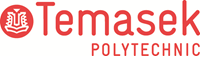

**TEMASEK POLYTECHNIC**
<br>**SCHOOL OF INFORMATICS & IT**
<br>**DIPLOMA IN INFORMATION TECHNOLOGY**
<br>**MACHINE LEARNING FOR DEVELOPERS (CAI2C08)**
<br>**AY2025/2026 OCTOBER SEMESTER**

**PROJECT PROGRAM CODES**
* Student Name (Matric Number)  : Muthiah S/O Nachiappan (2402087G)
* Tutorial Group                : PC03
* Tutor						    : Mr Ruchir Srivastava
* Submission Date               : 11/02/2026


**Declaration of Originality**
* I am the originator of this work and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [1]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly

# 1. Business Understanding
Goal: To predict whether a person earns >50K or <=50K per year based on a personal and work details of an individual such as (age, education, job type, hours worked, etc.).

# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## Read *.csv file into pandas DataFrame
dataset = "bank-full.csv"
df = pd.read_csv(dataset,sep=";")
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


The dataset is being loaded to the ipynb. When reading the dataset, i have to use the command sep as the data is only seperated by ; and not a new line.

## 2.2 Summary Statistics

In [3]:
## Understand the type of variable for each column
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

It is important to understand the data types for each column in the database because it affects data accuracy, validation, performance, and storage. If the wrong type is used, you can get issues like wrong sorting, calculation errors, or data being rejected or even end up in wrong modelling,inaccurate model training

In [4]:
## Check for missing data
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

df.isna().sum() is used to check for missing data in a DataFrame by counting how many null (NaN) values are present in each column. This is important because missing values can affect data analysis and machine learning results by causing errors or producing inaccurate outcomes. By identifying which columns contain missing data and how many values are missing, it helps you decide the best way to handle them, such as filling in the missing values, removing incomplete rows, or cleaning the dataset before further processing.

In [5]:
## Describe data distribution
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


df.decsribe() is used to check the distribution of data in numarical columns with statistical report

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

<Axes: xlabel='y'>

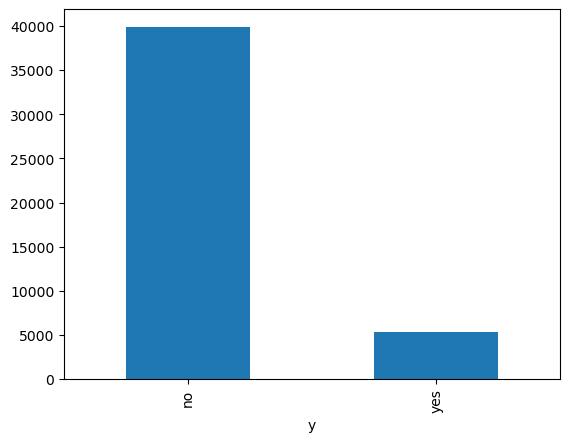

In [6]:
## Understanding distribution of target
col_y = "y"
df[col_y].value_counts().plot(kind='bar')

Checking the distribution of the target variable (in this case, income) is important because it helps you understand what kind of dataset you are working with before you start training any machine learning model. By looking at the distribution, you can identify whether the dataset is balanced or imbalanced. This matters because if one class appears much more frequently than the other, a model may become biased toward predicting the majority class most of the time. As a result, the model might achieve a seemingly high accuracy while still performing poorly on the minority class, which is often the more important class to detect.

The target variable is highly imbalanced, with the majority of customers not subscribing to the term deposit. This imbalance indicates that accuracy alone may be misleading, hence precision, recall, and F1-score were used to evaluate model performance.

### 2.3.1.2 Understanding distribution of features

<Axes: >

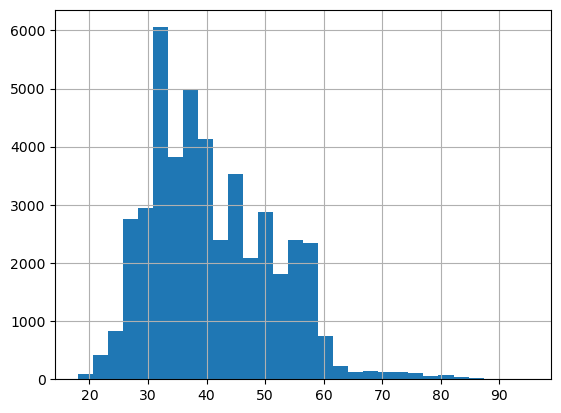

In [7]:
## Understanding distribution of features
df['age'].hist(bins=30)

Checking the age distribution is important as it helps me to understand the dirstribution of the ages of the respondents in the dataset.By analysing the dirstributions, i will be able to which age group dominates the data and also identify any potential biases in the dataset that might affect the analysis and the model. This would allow me to detect outliers that might be potentially due to error in data entry. Hence by checking the age distribution i will be able to ensure that the conclusions derived from the analysis are accurate and reliable

By analysing the histogram, i can conclude that the age dirstribution is mainly concentrated between 25 and 45 years old where in particularly there are more respondents around the early 30s age. The number of individuals gradually decreases after 45 and after 60 years old there are significantly fewer people. Therefore we can conclude that the age group distribution in the dataset is right skewed. Overall the graph suggests that the data primarily represents young to middle-aged adults rather than older populations

<Axes: >

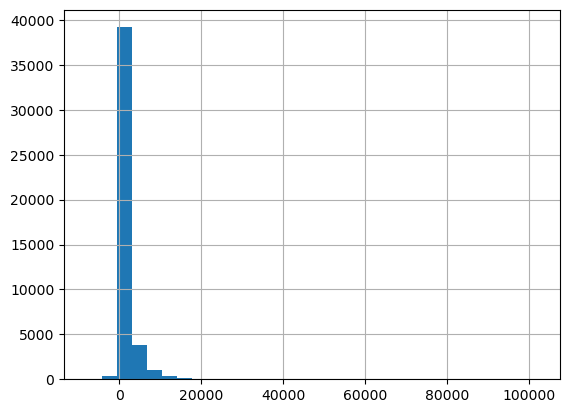

In [8]:
df['balance'].hist(bins=30)

Analysing the histogram for the variable 'balance' its very important as it helps me to understand how the customer's bank balance are disributed accross the dataset.

From the graph it clearly shows that the balance distribution is heavily right skewed. Additionally it shows that the respondents bank balance are close to zero, while a small number of customers have very large balances creating a more plots on the right side resulting in the distribution to be right skewed. This indicates that the respondents are mostly from customers who have less money in their bank account and the customers with high bank balances are less.

<Axes: >

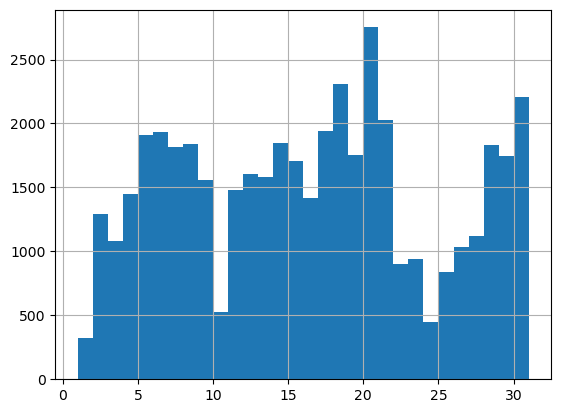

In [11]:
df['day'].hist(bins=30)

This graph is important as it helps me to understand whether customer contacts are evenly distributed throughout the month or concentrated on certain days. If there are specific days with higher frequencies, it may indicate operational patterns, campaign strategies, or customer response trends. Identifying such patterns can help in allowing the company to planning better for future marketing campaigns or resource allocation more effectively.

From the histogram, the distribution appears relatively spread across the days of the month, but some days such as around mid-month and at the end of the month the frequency is slightly higher. I overall the histogram is quite balances with no signs of skewness which suggests that phone calls are fairly distributed rather than focused on just a few specific days. Overall, the data does not show a strong imbalance across the month, but however the slight clustering might reflect campaign timing or business scheduling patterns.

<Axes: >

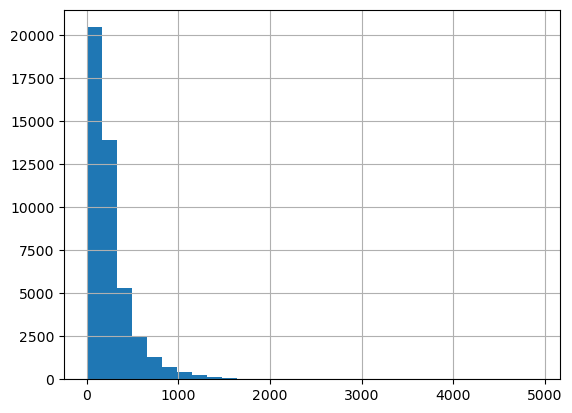

In [12]:
df['duration'].hist(bins=30)

The histogram of the duration variable is important because it helps me understand how long customer calls typically last and whether the data is evenly distributed. Since duration can strongly influence customer response or subscription outcomes, analysing its distribution allows me to identify patterns and detect extreme values.

From the graph, the duration distribution is heavily right-skewed. Most calls are short, concentrated below 500 seconds, while a small number of calls last much longer, extending beyond 1000 seconds and even higher. This indicates the presence of outliers where a few customers had unusually long conversations. Overall, the data suggests that short calls are common, while long calls are rare but might be significant.

<Axes: >

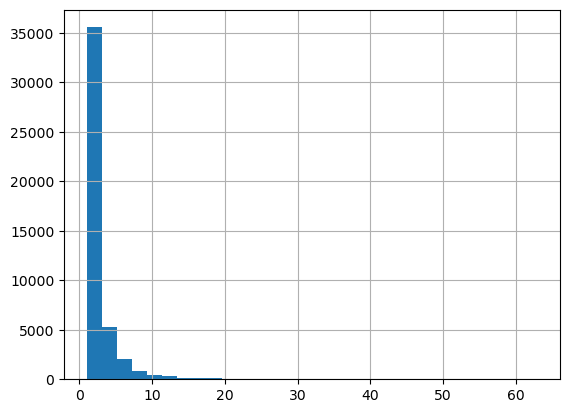

In [13]:
df['campaign'].hist(bins=30)

The histogram is important because it shows how many times each customer was contacted during the marketing campaign. Understanding this distribution helps me determine whether most customers were contacted only a few times or repeatedly. This is useful for evaluating campaign strategy and customer engagement levels. It also helps identify extreme values that may influence analysis or modeling.

From the graph, the campaign distribution is heavily right-skewed. Most customers were contacted only 1 to 3 times, while a small number of customers were contacted many more times, with some exceeding 10 or even higher. The frequency drops significantly as the number of contacts increases, indicating that repeated contact is relatively rare. This suggests that the campaign mainly relied on minimal contact attempts, with only a few customers receiving intensive follow-ups.

<Axes: >

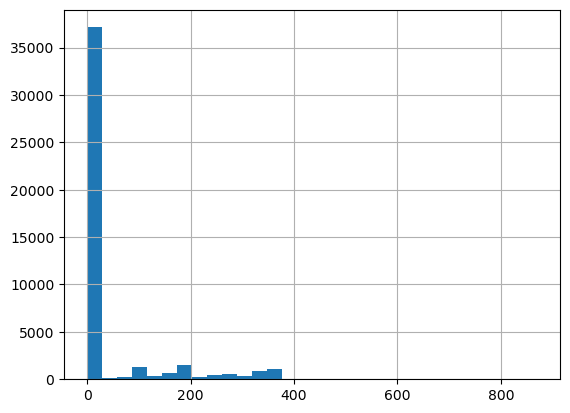

In [14]:
df['pdays'].hist(bins=30)

The histogram of the pdays variable is important because it shows the number of days that passed after a customer was last contacted from a previous campaign. This helps me understand how recent the previous contact was and whether most customers were contacted recently or a long time ago. Analysing this variable plays a pivotol role in telling me how the recency of contact can significantly influence customer response behaviour and prediction accuracy.

From the graph, there is a very large concentration at 0, which suggests that many customers were either not previously contacted or were contacted very recently. After that, the distribution spreads out with much smaller frequencies across higher values. The graph is strongly right-skewed, indicating that only a small number of customers were contacted long ago. This suggests that prior contact history is limited for most customers, while a minority have long gaps since their last interaction

<Axes: >

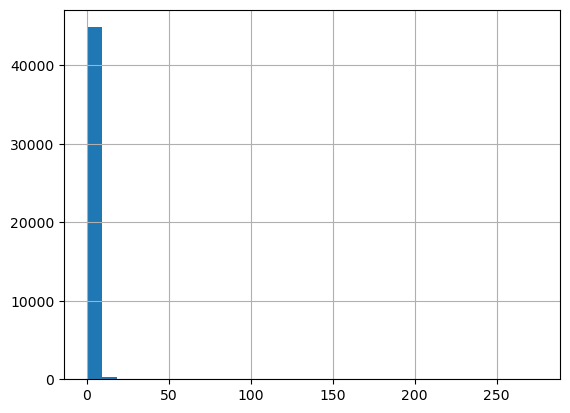

In [15]:
df['previous'].hist(bins=30)

This histogram is important because it helps me understand how many customers had been contacted in earlier marketing campaigns. This information is useful for analysing customer engagement history and determining whether the campaign is targeting new or previously contacted customers. It also helps in modelling, as customers with prior contact history may behave differently compared to those contacted for the first time.

From the graph, it is clear that the distribution is extremely right-skewed, with the majority of customers having 0 previous contacts. This indicates that most customers were being approached for the first time in this campaign. Only a small number of customers had been contacted one or more times previously. Overall, the data suggests that prior campaign interaction is limited for most customers.

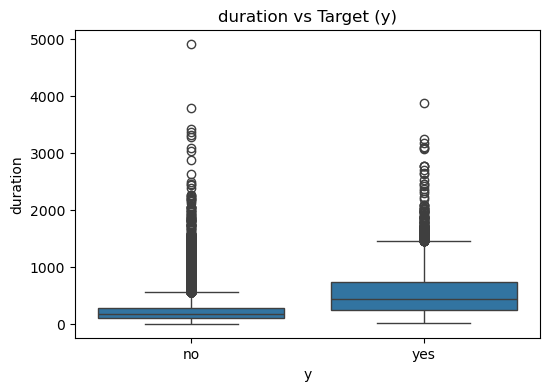

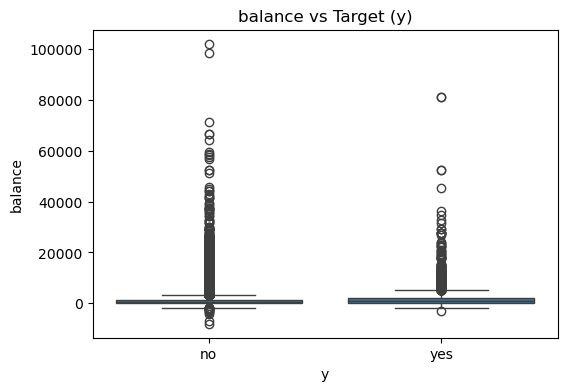

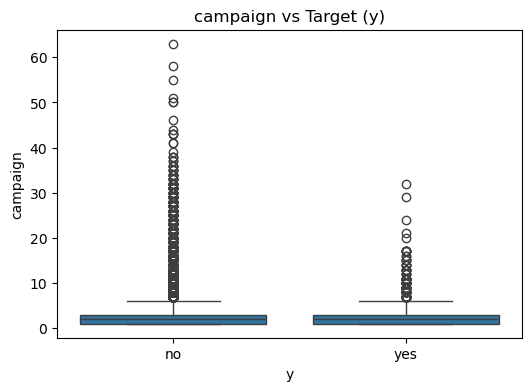

In [16]:
num_features = ["duration", "balance", "campaign"]

for col in num_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="y", y=col, data=df)
    plt.title(f"{col} vs Target (y)")
    plt.show()


These graphs shows how duration, balance and campaign during the campaign affects subscription success. 

For the first box plot it shows whether call duration influences whether a customer subscribes (yes) or not (no).From the boxplot, customers who answered “yes” generally have much longer call durations compared to those who answered “no”. The median duration for “yes” is clearly higher, and the spread is wider. This suggests that longer conversations are strongly associated with successful subscriptions.

For the second box plot which shows how ta customer’s bank balance affects their likelihood of subscribing. The median balance for customers who said “yes” appears slightly higher than those who said “no”, but the difference is not very large. There are many extreme outliers in both groups. This suggests that balance may have some influence, but it is not as strong a predictor as duration.

For the last box plot, it shows whether the number of contact attempts during the campaign affects subscription success. After analysing the box plot, customers who said “yes” generally required fewer contact attempts compared to some “no” customers who were contacted many times. The distribution shows that excessive contact does not necessarily increase success. In fact, higher campaign counts appear more common in the “no” group, suggesting repeated calls may reduce effectiveness.

In conclusion, the box plots shows that most successful subscriptions occurred with fewer contact attempts, whereas repeated calls were more common among customers who did not subscribe. This suggests that longer, meaningful conversations are more effective than frequent repeated contacts in achieving successful outcomes.

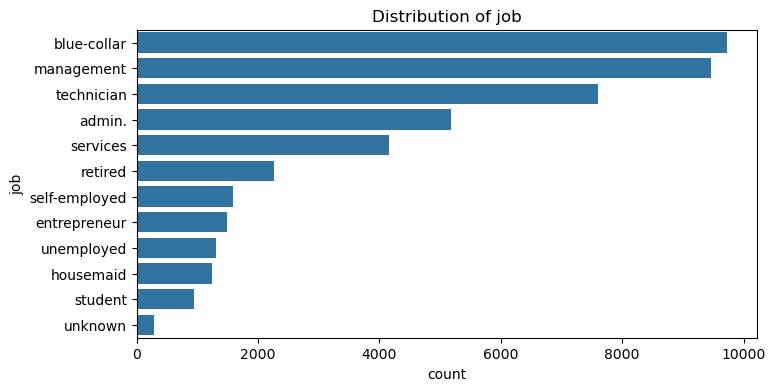

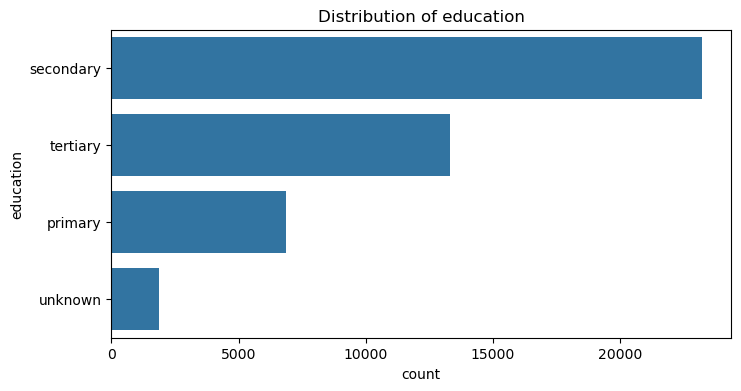

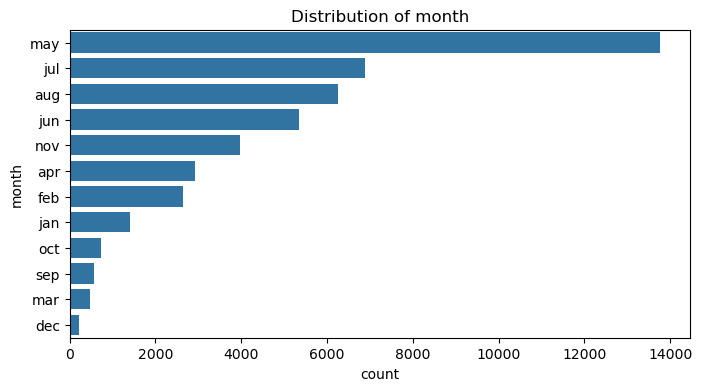

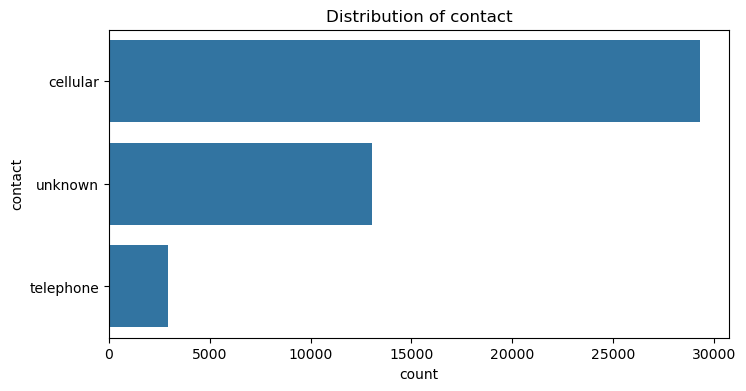

In [17]:
cat_features = ["job", "education", "month", "contact"]

for col in cat_features:
    plt.figure(figsize=(8,4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.show()


## Distribution of Job

Understanding the job distribution is important as it helps me understand the occupational background of customers in the dataset. This is because the differance in job types may influence the income level and the likelihood of subscribing.Knowing which job groups dominate the dataset also helps identify potential bias.

From the graph, the majority of customers are from blue-collar, management, and technician roles. Fewer customers belong to categories such as student, unemployed, or unknown. This indicates that the dataset mainly consists of working professionals, especially manual and technical workers.

## Distribution of Education

Education level is important because  this distribution helps me understand the educational background of customers and whether it is balanced.

The graph shows that most customers have secondary education, followed by tertiary education, while fewer customers have primary or unknown education levels. This suggests that the dataset mainly represents moderately educated individuals. Since secondary education dominates, results will reflect the behaviour of this group more strongly.

## Distribution of Month

The month distribution is important because it shows when marketing campaigns were most active. This is because campaign timing might affect customer response due to a multitude of factors.

The graph indicates that most contacts occurred in May, followed by July and August. Very few contacts happened in months such as December and March. This suggests that marketing activity was concentrated in certain months rather than evenly spread throughout the year.

## Distribution of Contact

The contact method distribution is important because it shows how customers were approached (cellular, telephone, or unknown( which most likely means in person)).

The graph shows that the majority of contacts were made via cellular, followed by unknown, with very few using traditional telephone. This suggests that mobile communication was the primary method used in the campaign. Since cellular dominates, campaign effectiveness may largely reflect the performance of this contact method.


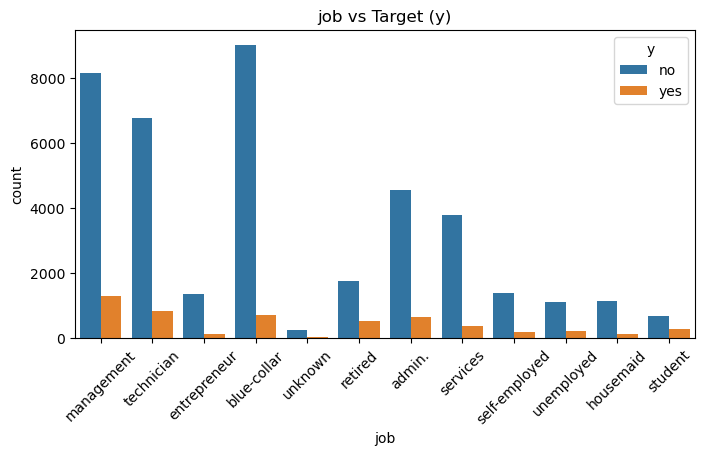

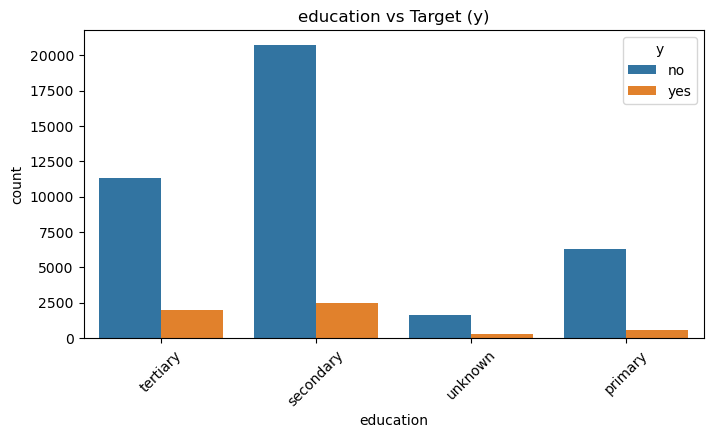

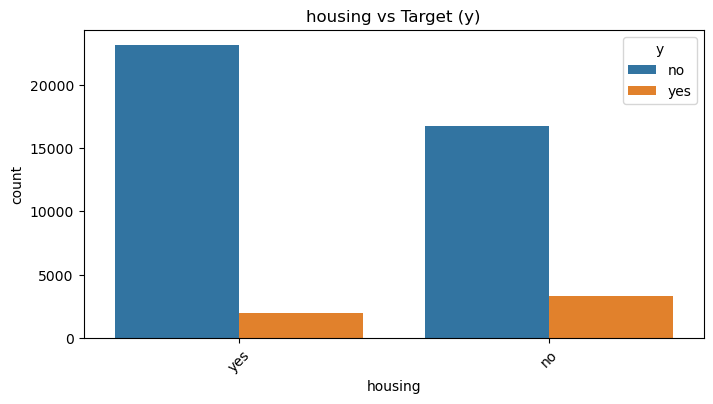

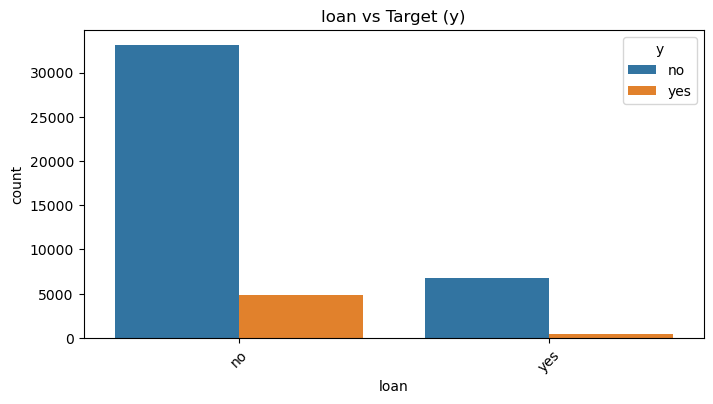

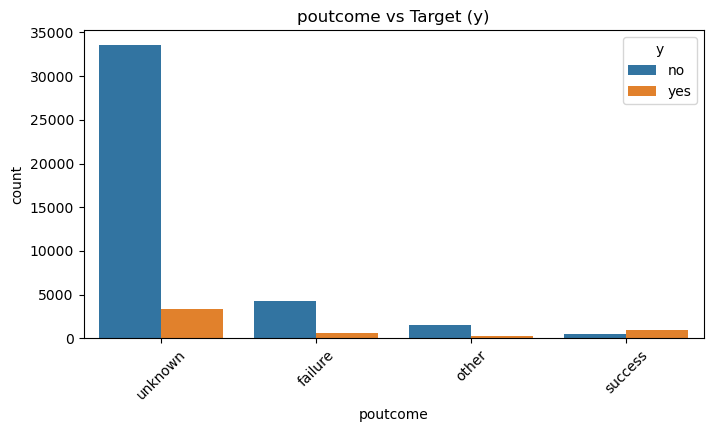

In [18]:
for col in ["job", "education", "housing", "loan", "poutcome"]:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, hue="y")
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Target (y)")
    plt.show()


## Bar Chart(Job VS Target(y))

This graph is important because it shows how subscription outcomes differ across job categories.

Across all job categories, the number of “no” responses is higher than “yes”. However, management, technician, and admin roles show relatively higher numbers of “yes” compared to other occupations. Blue-collar workers have a high number of contacts but comparatively fewer subscriptions proportionally. This suggests that occupation may influence response rates, with some professional roles showing slightly better outcomes.

## Bar Chart(Education VS Target(y))

This graph helps determine whether subscription rates vary based on educational background.

Most customers have secondary education, and this group also has the highest number of subscriptions in absolute terms. However, tertiary education appears to show a relatively strong number of “yes” responses proportionally. Primary and unknown education groups show fewer subscriptions. This suggests that higher education levels may slightly increase the likelihood of subscribing.

## Bar Chart(Housing VS Target(y))

This graph helps analyse whether customers with housing loans are more or less likely to subscribe.

Customers without housing loans show a higher number of “yes” responses compared to those with housing loans. Although both groups have more “no” responses overall, customers with housing loans appear less likely to subscribe. This suggests that financial commitments such as loans reduce willingness to invest in additional products.

## Bar Chart(Loan VS Target(y))

This graph helps analyse whether having a personal loan affects subscription behaviour.

Customers without personal loans have significantly more subscriptions compared to those with loans. Those who already have loans show very few “yes” responses. This strongly suggests that customers without existing loans are more likely to subscribe.

## Bar Chart (Previous Outcome (poutcome) vs Target (y))

This graph is very important because it shows how the outcome of a previous campaign influences current subscription decisions.

Customers with a previous “success” outcome show a much higher proportion of “yes” responses compared to other categories. In contrast, “failure” and “unknown” groups have mostly “no” responses. This indicates that past successful interactions strongly increase the likelihood of future subscriptions.

##  BoxPlot Analysis

age            Axes(0.125,0.11;0.0945122x0.77)
balance     Axes(0.238415,0.11;0.0945122x0.77)
day         Axes(0.351829,0.11;0.0945122x0.77)
duration    Axes(0.465244,0.11;0.0945122x0.77)
campaign    Axes(0.578659,0.11;0.0945122x0.77)
pdays       Axes(0.692073,0.11;0.0945122x0.77)
previous    Axes(0.805488,0.11;0.0945122x0.77)
dtype: object

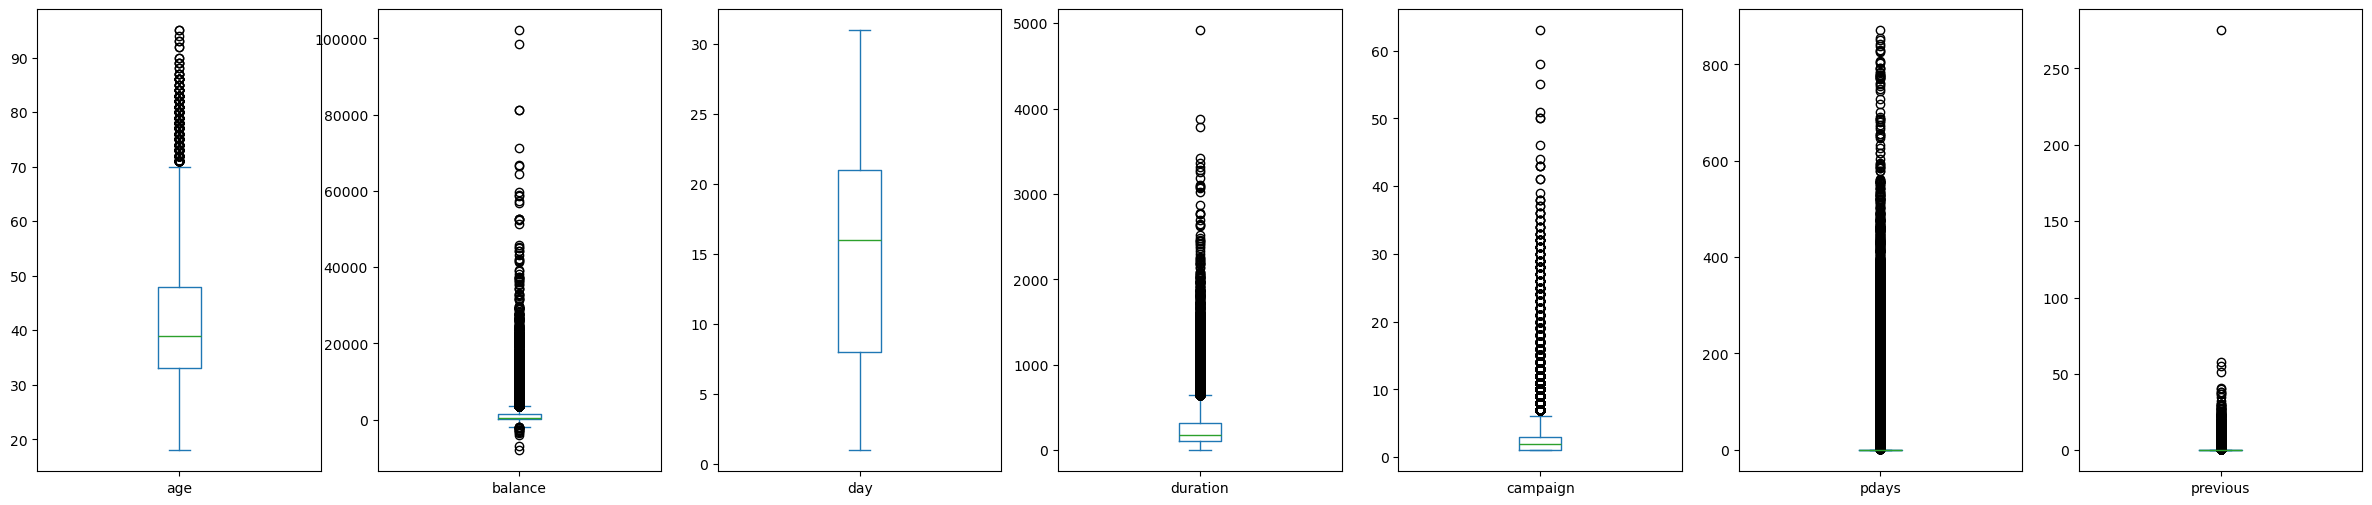

In [9]:
df.plot(kind='box', subplots=True, layout=(1,7), figsize=(30,6))

The boxplots are important because they provide a summary of the distribution, spread, median, and presence of outliers for all numerical variables in the dataset. 

By Analysing the box plots, variables such as balance, duration, campaign, pdays, and previous show strong right-skewness with many outliers, indicating the presence of extreme high values. In contrast, age and day appear more evenly distributed with fewer extreme values.

### 2.3.2 Understanding relationship between variables

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000


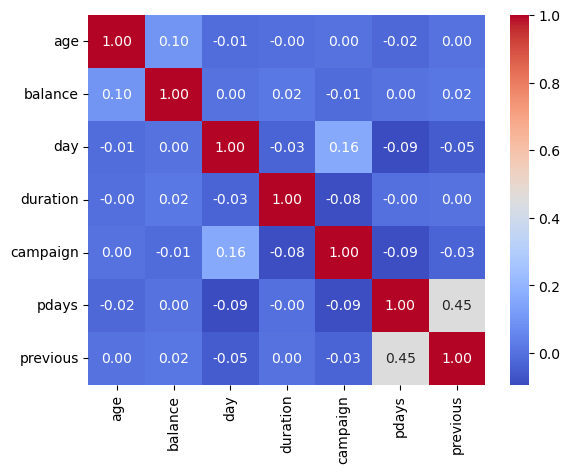

In [10]:
## Understanding relationship between variables
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
corr

The correlation heatmap is important because it shows the strength and direction of relationships between all numerical variables in the dataset. 

From the heatmap, most variables show very weak correlations (values close to 0), indicating that they are largely independent of one another. The only moderate positive correlation appears between pdays and previous (0.45), suggesting that customers who were contacted more times previously tend to have longer gaps since last contact. Other relationships, such as between age and balance (0.10) or campaign and day (0.16), are relatively weak and not strong enough to indicate significant dependence. Overall, the dataset does not show any feature having strong correalation, which is therefore suitable for predictive modelling.

# 3. Data Preparation

## 3.1 Data Cleaning

In [19]:
## Clean data
df= df.drop(df[df["job"] == "unknown"].index)

This step removes rows that have the job value as“unknown” to improve data quality and reliability. Keeping the unknown category will cause noise and reduce the accuracy for analysis and might also possibly affect modelling. By dropping these rows, the dataset becomes cleaner and more representative and less noisy making it sutiable for making analysis and modelling

In [20]:
df.duplicated().sum()

np.int64(0)

This step will check if there are any duplicate rows in the dataset. This duplicate data will make the data noisy and thus affect the accuracy of predictions and modelling

In [21]:
df["pdays_contacted"] = (df["pdays"] != 999).astype(int)
df["pdays"] = df["pdays"].replace(999, -1)


I created pdays_contacted to indicate whether a customer was previously contacted (1 = yes, 0 = no). Since 999 is just a placeholder meaning no previous contact, I replaced it with -1 to prevent the model from misinterpreting it as a real number of days.

In [22]:
df["y"] = df["y"].map({"no": 0, "yes": 1})
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,pdays_contacted
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0,1
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,1,1
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,1,1
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,1,1
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,0,1


This line converts the target variable y from categorical values “no” and “yes” into numerical values 0 and 1. I mapped “no” to 0 and “yes” to 1 so that the data can be used for modelling.

In [23]:
##Split the y column which is the target column from the rest
y = df['y']
X = df.drop(['y'],axis=1)
X = pd.get_dummies(X)
X

,age,balance,day,duration,campaign,pdays,previous,pdays_contacted,job_admin.,job_blue-collar,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,261,1,-1,0,1,False,False,...,False,False,True,False,False,False,False,False,False,True
1,44,29,5,151,1,-1,0,1,False,False,...,False,False,True,False,False,False,False,False,False,True
2,33,2,5,76,1,-1,0,1,False,False,...,False,False,True,False,False,False,False,False,False,True
3,47,1506,5,92,1,-1,0,1,False,True,...,False,False,True,False,False,False,False,False,False,True
5,35,231,5,139,1,-1,0,1,False,False,...,False,False,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,825,17,977,3,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True
45207,71,1729,17,456,2,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True
45208,72,5715,17,1127,5,184,3,1,False,False,...,False,False,False,True,False,False,False,False,True,False
45209,57,668,17,508,4,-1,0,1,False,True,...,False,False,False,True,False,False,False,False,False,True


I separated the target variable y from the rest of the features by assigning it to y, and stored all other variables in X. Then, I used pd.get_dummies(X) to convert the categorical variables into numerical format using one-hot encoding. This ensures the data is properly prepared for modelling, as modals only accept binary or numerical inputs

## 3.2 Train-Test Split

In [24]:
from sklearn.model_selection import train_test_split
test_size = 0.3
random_state = 10000
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=test_size, random_state=random_state )

# 4. Modelling

### 4.2 Train Model

In [25]:
##Baseline Model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)
model.fit(X_train,y_train)
y_probs = model.predict_proba(X_test)[:, 1]

for t in [0.3, 0.4, 0.5, 0.6,0.65]:
    y_pred_t = (y_probs >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_t))



Threshold: 0.3
              precision    recall  f1-score   support

           0       0.99      0.70      0.82     11943
           1       0.28      0.94      0.44      1534

    accuracy                           0.72     13477
   macro avg       0.64      0.82      0.63     13477
weighted avg       0.91      0.72      0.77     13477


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.98      0.78      0.87     11943
           1       0.34      0.89      0.49      1534

    accuracy                           0.79     13477
   macro avg       0.66      0.83      0.68     13477
weighted avg       0.91      0.79      0.83     13477


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.97      0.83      0.90     11943
           1       0.39      0.83      0.53      1534

    accuracy                           0.83     13477
   macro avg       0.68      0.83      0.71     13477
weighted avg       0.91   

c:\Users\muthiah\anaconda3\envs\mldp\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# 5. Model Evaluation

In [ ]:
## Evaluate model


In [ ]:
## New data

## Predict


## Iterative model development


In [ ]:
## Further feature engineering / feature selection